In [1]:
import sys
sys.path.append('..')
import numpy as np
import brainpy as bp
import brainpy.math as bm
import matplotlib.pyplot as plt
from CANN_DDM_model import CANN_DDM_model
from tqdm import tqdm
import pickle
import seaborn as sns
import json
import matplotlib.lines as mlines
from matplotlib.colors import ListedColormap, to_rgba

/projectnb/ecog-eeg/cyw6/.conda/envs/cann_ddm_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('../results/model_config_default.json') as data:
    CANN_params = json.load(data)
    decision_space_params = CANN_params['decision_space_params']
    edge_pop = CANN_params['edge_pop']
    bump_pop = CANN_params['bump_pop']

In [3]:
# 基础颜色
base_color = '#1d52a1'

# 创建 alpha 渐变 (从透明到不透明)
n = 256
colors = [to_rgba(base_color, alpha=a) for a in np.linspace(0, 1, n)]

# 生成 colormap
cmap = ListedColormap(colors, name='blue_alpha')

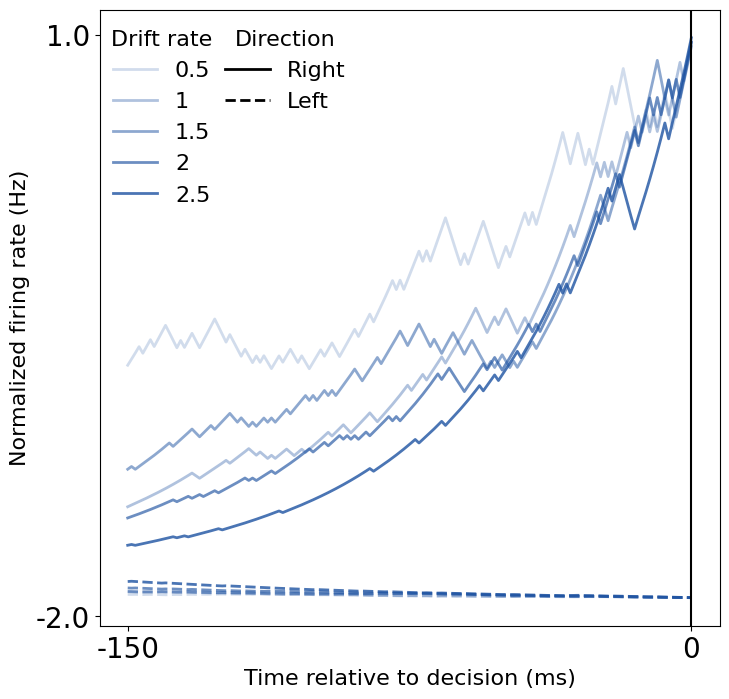

In [4]:
pos_offset = 0.003
idx = 350  # example neuron index
t_start = 200
drift_rates = [-0.5, -1, -1.5, -2, -2.5]
#cmap = plt.get_cmap('Reds')
colors = cmap(np.linspace(0.2, 0.8, len(drift_rates)))

plt.figure(figsize=(8, 8))
for rate, color in zip(drift_rates, colors):
    for direction in [1, -1]:
        # Update simulation parameters
        decision_space_params.update({'seed': 2025, 'drift_rate': rate * direction})
        CANN_params.update({'decision_space_params': decision_space_params})
        model = CANN_DDM_model(CANN_params=CANN_params)
        
        # Run simulation
        mon_vars = ['x_E', 'r_E', 'U_E', 'hit_boundary']
        runner, RT = model.run_simulation(mon_vars=mon_vars, progress_bar=False, pos_offset=pos_offset, get_RT=True)
        
        # Extract window relative to decision time
        start_idx = int(t_start + RT) - 150
        end_idx = int(t_start + RT)
        fr = runner.mon.U_E[start_idx:end_idx, idx]
        
        # x axis: time relative to decision boundary
        x = np.linspace(-150, 0, len(fr))
        if direction == 1:
            plt.plot(x, fr, color=color, linewidth=2)
        else:
            plt.plot(x, fr, color=color, linewidth=2, linestyle='--')

# Vertical line at decision boundary (time 0)
plt.axvline(0, color='black', alpha=1)

# Axis ticks and labels
ax = plt.gca()
ax.set_xticks([-150, 0])
ax.set_xticklabels(['-150', '0'], fontsize=20)
ax.set_yticks([-2, 1])
ax.set_yticklabels(['-2.0', '1.0'], fontsize=20)

# Axis labels
ax.set_xlabel('Time relative to decision (ms)', fontsize=16)
ax.set_ylabel('Normalized firing rate (Hz)', fontsize=16)

# =====================
# Add two separate legends
# =====================
import matplotlib.lines as mlines

# Legend for drift rates (colors)
drift_handles = []
for rate, color in zip(drift_rates, colors):
    handle = mlines.Line2D([], [], color=color, linewidth=2, label=f'{np.abs(rate)}')
    drift_handles.append(handle)

# Legend for directions (line styles)
direction_handles = [
    mlines.Line2D([], [], color='black', linewidth=2, linestyle='-', label='Right'),
    mlines.Line2D([], [], color='black', linewidth=2, linestyle='--', label='Left')
]

# First legend (drift rate)
first_legend = ax.legend(handles=drift_handles, 
                         title="Drift rate", 
                         loc='upper center',
                         bbox_to_anchor=(0.1, 1),   # adjust horizontal position
                         fontsize=16, title_fontsize=16,
                         frameon=False)  # remove box
ax.add_artist(first_legend)

# Second legend (direction) right next to the first
ax.legend(handles=direction_handles, 
          title="Direction", 
          loc='upper center',
          bbox_to_anchor=(0.3, 1),   # place to the right
          fontsize=16, title_fontsize=16,
          frameon=False)  # remove box

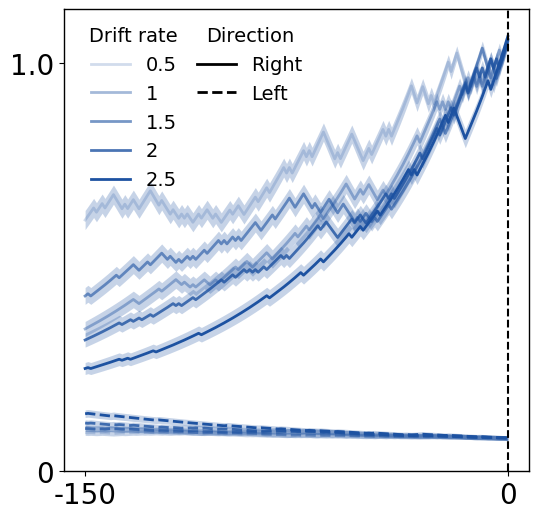

In [9]:
pos_offset = 0.003
idx = np.arange(300, 450)  # example neuron index
t_start = 200
drift_rates = [-0.5, -1, -1.5, -2, -2.5]
#cmap = plt.get_cmap('Reds')
colors = cmap(np.linspace(0.2, 1, len(drift_rates)))

plt.figure(figsize=(6, 6))
for rate, color in zip(drift_rates, colors):
    for direction in [1, -1]:
        # Update simulation parameters
        decision_space_params.update({'seed': 2025, 'drift_rate': rate * direction})
        CANN_params.update({'decision_space_params': decision_space_params})
        model = CANN_DDM_model(CANN_params=CANN_params)
        
        # Run simulation
        mon_vars = ['x_E', 'r_E', 'U_E', 'hit_boundary']
        runner, RT = model.run_simulation(mon_vars=mon_vars, progress_bar=False, pos_offset=pos_offset, get_RT=True)
        
        # Extract window relative to decision time
        start_idx = int(t_start + RT) - 150
        end_idx = int(t_start + RT)
        # --------- Compute mean ± SEM ---------
        U_window = runner.mon.U_E[start_idx:end_idx, idx]  # shape (time, neuron)
        fr_mean = np.mean(U_window, axis=1)
        fr_sem = np.std(U_window, axis=1, ddof=1) / np.sqrt(U_window.shape[1])
        
        # --------- Time axis ---------
        x = np.linspace(-150, 0, len(fr_mean))

        # --------- Plot mean line ---------
        linestyle = '-' if direction == 1 else '--'
        plt.plot(x, fr_mean, color=color, lw=2, linestyle=linestyle)

        # --------- Error band (SEM) ---------
        plt.fill_between(x,
                         fr_mean - fr_sem,
                         fr_mean + fr_sem,
                         color=color,
                         alpha=0.25,
                         linewidth=0)

# Vertical line at decision boundary (time 0)
plt.axvline(0, color='black', alpha=1, linestyle='--')

# Axis ticks and labels
ax = plt.gca()
ax.set_xticks([-150, 0])
ax.set_xticklabels(['-150', '0'], fontsize=20)
ax.set_yticks([-2, 1])
ax.set_yticklabels(['0', '1.0'], fontsize=20)


# display the frame of the plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

# Axis labels
#ax.set_xlabel('Time relative to decision (ms)', fontsize=16)
#ax.set_ylabel('Normalized firing rate (Hz)', fontsize=16)

# =====================
# Add two separate legends
# =====================
# Legend for drift rates (colors)
drift_handles = []
for rate, color in zip(drift_rates, colors):
    handle = mlines.Line2D([], [], color=color, linewidth=2, label=f'{np.abs(rate)}')
    drift_handles.append(handle)

# Legend for directions (line styles)
direction_handles = [
    mlines.Line2D([], [], color='black', linewidth=2, linestyle='-', label='Right'),
    mlines.Line2D([], [], color='black', linewidth=2, linestyle='--', label='Left')
]

# First legend (drift rate)
first_legend = ax.legend(handles=drift_handles, 
                         title="Drift rate", 
                         loc='upper center',
                         bbox_to_anchor=(0.15, 1),   # adjust horizontal position
                         fontsize=14, title_fontsize=14,
                         frameon=False)  # remove box
ax.add_artist(first_legend)

# Second legend (direction) right next to the first
ax.legend(handles=direction_handles, 
          title="Direction", 
          loc='upper center',
          bbox_to_anchor=(0.4, 1),   # place to the right
          fontsize=14, title_fontsize=14,
          frameon=False)  # remove box
